# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs
Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus

### **Setting Base Directory**

In [3]:
%cd ..
%cd ..
!mkdir content
%cd content

/kaggle
/
mkdir: cannot create directory ‘content’: File exists
/content


### **Setting up Roboflow**

In [5]:
!pip install roboflow

from roboflow import Roboflow
import os

rf = Roboflow(api_key="XaYRaTIxrFcAN0CfHjEN")
project = rf.workspace("ahmed-ws").project("pannuke-gan-augmented")
version = project.version(2)
dataset = version.download("sam2")
                

# rename dataset.location to "data"
os.rename(dataset.location, "/content/data")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PanNuke-GAN-Augmented-2 in sam2:: 100%|██████████| 15339/15339 [00:03<00:00, 4146.23it/s]


### **Loading SAMv2**

In [6]:
!git clone https://github.com/facebookresearch/sam2.git

Cloning into 'sam2'...
remote: Enumerating objects: 1070, done.
remote: Counting objects: 100% (477/477), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 1070 (delta 322), reused 279 (delta 279), pack-reused 593 (from 1)
Receiving objects: 100% (1070/1070), 115.76 MiB | 36.29 MiB/s, done.
Resolving deltas: 100% (416/416), done.


In [7]:
!wget -O /content/sam2/sam2/configs/train.yaml 'https://drive.usercontent.google.com/download?id=11cmbxPPsYqFyWq87tmLgBAQ6OZgEhPG3'

--2025-04-13 13:18:06--  https://drive.usercontent.google.com/download?id=11cmbxPPsYqFyWq87tmLgBAQ6OZgEhPG3
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.69.132, 2607:f8b0:4001:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11055 (11K) [application/octet-stream]
Saving to: ‘/content/sam2/sam2/configs/train.yaml’

/content/sam2/sam2/ 100%[===================>]  10.80K  --.-KB/s    in 0.001s  

2025-04-13 13:18:09 (18.6 MB/s) - ‘/content/sam2/sam2/configs/train.yaml’ saved [11055/11055]



In [8]:
%cd ./sam2/

/content/sam2


In [9]:
!pip install -e .[dev] -q

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 90.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7

### **Loading Checkpoints**

In [10]:
!cd ./checkpoints && ./download_ckpts.sh

--2025-04-13 13:23:47--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.118, 3.171.22.33, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_tiny.pt’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M   193MB/s    in 0.8s    

2025-04-13 13:23:48 (193 MB/s) - ‘sam2.1_hiera_tiny.pt’ saved [156008466/156008466]

--2025-04-13 13:23:48--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.13, 3.171.22.33, 3.171.22.118, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 184416285 (176M) [application/v

In [11]:
# Script to rename roboflow filenames to something SAM 2.1 compatible.
# Maybe it is possible to remove this step tweaking sam2/sam2/configs/train.yaml.
import os
import re

FOLDER = "/content/data/train"

for filename in os.listdir(FOLDER):
    # Replace all except last dot with underscore
    new_filename = filename.replace(".", "_", filename.count(".") - 1)
    if not re.search(r"_\d+\.\w+$", new_filename):
        # Add an int to the end of base name
        new_filename = new_filename.replace(".", "_1.")
    os.rename(os.path.join(FOLDER, filename), os.path.join(FOLDER, new_filename))

### **Updating model config to reduce epochs**

In [15]:
%%writefile sam2/configs/train.yaml
# @package _global_

scratch:
  resolution: 1024
  train_batch_size: 1
  num_train_workers: 10
  num_frames: 1
  max_num_objects: 3
  base_lr: 5.0e-6
  vision_lr: 3.0e-06
  phases_per_epoch: 1
  num_epochs: 1

dataset:
  # PATHS to Dataset
  img_folder: /content/data/train # PATH to MOSE JPEGImages folder
  gt_folder: /content/data/train  # PATH to MOSE Annotations folder
  #file_list_txt: training/assets/MOSE_sample_train_list.txt # Optional PATH to filelist containing a subset of videos to be used for training
  multiplier: 2

# Video transforms
vos:
  train_transforms:
    - _target_: training.dataset.transforms.ComposeAPI
      transforms:
        - _target_: training.dataset.transforms.RandomHorizontalFlip
          consistent_transform: True
        - _target_: training.dataset.transforms.RandomAffine
          degrees: 25
          shear: 20
          image_interpolation: bilinear
          consistent_transform: True
        - _target_: training.dataset.transforms.RandomResizeAPI
          sizes: ${scratch.resolution}
          square: true
          consistent_transform: True
        - _target_: training.dataset.transforms.ColorJitter
          consistent_transform: True
          brightness: 0.1
          contrast: 0.03
          saturation: 0.03
          hue: null
        - _target_: training.dataset.transforms.RandomGrayscale
          p: 0.05
          consistent_transform: True
        - _target_: training.dataset.transforms.ColorJitter
          consistent_transform: False
          brightness: 0.1
          contrast: 0.05
          saturation: 0.05
          hue: null
        - _target_: training.dataset.transforms.ToTensorAPI
        - _target_: training.dataset.transforms.NormalizeAPI
          mean: [0.485, 0.456, 0.406]
          std: [0.229, 0.224, 0.225]

trainer:
  _target_: training.trainer.Trainer
  mode: train_only
  max_epochs: ${times:${scratch.num_epochs},${scratch.phases_per_epoch}}
  accelerator: cuda
  seed_value: 123

  model:
    _target_: training.model.sam2.SAM2Train
    image_encoder:
      _target_: sam2.modeling.backbones.image_encoder.ImageEncoder
      scalp: 1
      trunk:
        _target_: sam2.modeling.backbones.hieradet.Hiera
        embed_dim: 112
        num_heads: 2
        drop_path_rate: 0.1
      neck:
        _target_: sam2.modeling.backbones.image_encoder.FpnNeck
        position_encoding:
          _target_: sam2.modeling.position_encoding.PositionEmbeddingSine
          num_pos_feats: 256
          normalize: true
          scale: null
          temperature: 10000
        d_model: 256
        backbone_channel_list: [896, 448, 224, 112]
        fpn_top_down_levels: [2, 3]  # output level 0 and 1 directly use the backbone features
        fpn_interp_model: nearest

    memory_attention:
      _target_: sam2.modeling.memory_attention.MemoryAttention
      d_model: 256
      pos_enc_at_input: true
      layer:
        _target_: sam2.modeling.memory_attention.MemoryAttentionLayer
        activation: relu
        dim_feedforward: 2048
        dropout: 0.1
        pos_enc_at_attn: false
        self_attention:
          _target_: sam2.modeling.sam.transformer.RoPEAttention
          rope_theta: 10000.0
          feat_sizes: [32, 32]
          embedding_dim: 256
          num_heads: 1
          downsample_rate: 1
          dropout: 0.1
        d_model: 256
        pos_enc_at_cross_attn_keys: true
        pos_enc_at_cross_attn_queries: false
        cross_attention:
          _target_: sam2.modeling.sam.transformer.RoPEAttention
          rope_theta: 10000.0
          feat_sizes: [32, 32]
          rope_k_repeat: True
          embedding_dim: 256
          num_heads: 1
          downsample_rate: 1
          dropout: 0.1
          kv_in_dim: 64
      num_layers: 4

    memory_encoder:
        _target_: sam2.modeling.memory_encoder.MemoryEncoder
        out_dim: 64
        position_encoding:
          _target_: sam2.modeling.position_encoding.PositionEmbeddingSine
          num_pos_feats: 64
          normalize: true
          scale: null
          temperature: 10000
        mask_downsampler:
          _target_: sam2.modeling.memory_encoder.MaskDownSampler
          kernel_size: 3
          stride: 2
          padding: 1
        fuser:
          _target_: sam2.modeling.memory_encoder.Fuser
          layer:
            _target_: sam2.modeling.memory_encoder.CXBlock
            dim: 256
            kernel_size: 7
            padding: 3
            layer_scale_init_value: 1e-6
            use_dwconv: True  # depth-wise convs
          num_layers: 2

    num_maskmem: 7
    image_size: ${scratch.resolution}
    # apply scaled sigmoid on mask logits for memory encoder, and directly feed input mask as output mask
    sigmoid_scale_for_mem_enc: 20.0
    sigmoid_bias_for_mem_enc: -10.0
    use_mask_input_as_output_without_sam: true
    # Memory
    directly_add_no_mem_embed: true
    no_obj_embed_spatial: true
    # use high-resolution feature map in the SAM mask decoder
    use_high_res_features_in_sam: true
    # output 3 masks on the first click on initial conditioning frames
    multimask_output_in_sam: true
    # SAM heads
    iou_prediction_use_sigmoid: True
    # cross-attend to object pointers from other frames (based on SAM output tokens) in the encoder
    use_obj_ptrs_in_encoder: true
    add_tpos_enc_to_obj_ptrs: true
    proj_tpos_enc_in_obj_ptrs: true
    use_signed_tpos_enc_to_obj_ptrs: true
    only_obj_ptrs_in_the_past_for_eval: true
    # object occlusion prediction
    pred_obj_scores: true
    pred_obj_scores_mlp: true
    fixed_no_obj_ptr: true
    # multimask tracking settings
    multimask_output_for_tracking: true
    use_multimask_token_for_obj_ptr: true
    multimask_min_pt_num: 0
    multimask_max_pt_num: 1
    use_mlp_for_obj_ptr_proj: true
    # Compilation flag
    # compile_image_encoder: False

    ####### Training specific params #######
    # box/point input and corrections
    prob_to_use_pt_input_for_train: 0.5
    prob_to_use_pt_input_for_eval: 0.0
    prob_to_use_box_input_for_train: 0.5  # 0.5*0.5 = 0.25 prob to use box instead of points
    prob_to_use_box_input_for_eval: 0.0
    prob_to_sample_from_gt_for_train: 0.1  # with a small prob, sampling correction points from GT mask instead of prediction errors
    num_frames_to_correct_for_train: 2  # iteratively sample on random 1~2 frames (always include the first frame)
    num_frames_to_correct_for_eval: 1  # only iteratively sample on first frame
    rand_frames_to_correct_for_train: True  # random #init-cond-frame ~ 2
    add_all_frames_to_correct_as_cond: True  # when a frame receives a correction click, it becomes a conditioning frame (even if it's not initially a conditioning frame)
    # maximum 2 initial conditioning frames
    num_init_cond_frames_for_train: 2
    rand_init_cond_frames_for_train: True  # random 1~2
    num_correction_pt_per_frame: 7
    use_act_ckpt_iterative_pt_sampling: false
    

    
    num_init_cond_frames_for_eval: 1  # only mask on the first frame
    forward_backbone_per_frame_for_eval: True
    

  data:
    train:
      _target_: training.dataset.sam2_datasets.TorchTrainMixedDataset
      phases_per_epoch: ${scratch.phases_per_epoch}
      batch_sizes:
        - ${scratch.train_batch_size}

      datasets:
        - _target_: training.dataset.vos_dataset.VOSDataset
          transforms: ${vos.train_transforms}
          training: true
          video_dataset:
            _target_: training.dataset.vos_raw_dataset.SA1BRawDataset
            img_folder: ${dataset.img_folder}
            gt_folder: ${dataset.gt_folder}
            # file_list_txt: ${dataset.file_list_txt}
          multiplier: ${dataset.multiplier}
          sampler:
            _target_: training.dataset.vos_sampler.RandomUniformSampler
            num_frames: 1
            max_num_objects: ${scratch.max_num_objects}
      shuffle: True
      num_workers: ${scratch.num_train_workers}
      pin_memory: True
      drop_last: True
      collate_fn:
        _target_: training.utils.data_utils.collate_fn
        _partial_: true
        dict_key: all

  optim:
    amp:
      enabled: True
      amp_dtype: bfloat16

    optimizer:
      _target_: torch.optim.AdamW

    gradient_clip:
      _target_: training.optimizer.GradientClipper
      max_norm: 0.1
      norm_type: 2

    param_group_modifiers:
      - _target_: training.optimizer.layer_decay_param_modifier
        _partial_: True
        layer_decay_value: 0.9
        apply_to: 'image_encoder.trunk'
        overrides:
          - pattern: '*pos_embed*'
            value: 1.0

    options:
      lr:
        - scheduler:
            _target_: fvcore.common.param_scheduler.CosineParamScheduler
            start_value: ${scratch.base_lr}
            end_value: ${divide:${scratch.base_lr},10}
        - scheduler:
            _target_: fvcore.common.param_scheduler.CosineParamScheduler
            start_value: ${scratch.vision_lr}
            end_value: ${divide:${scratch.vision_lr},10}
          param_names:
            - 'image_encoder.*'
      weight_decay:
        - scheduler:
            _target_: fvcore.common.param_scheduler.ConstantParamScheduler
            value: 0.1
        - scheduler:
            _target_: fvcore.common.param_scheduler.ConstantParamScheduler
            value: 0.0
          param_names:
            - '*bias*'
          module_cls_names: ['torch.nn.LayerNorm']

  loss:
    all:
      _target_: training.loss_fns.MultiStepMultiMasksAndIous
      weight_dict:
        loss_mask: 20
        loss_dice: 1
        loss_iou: 1
        loss_class: 1
      supervise_all_iou: true
      iou_use_l1_loss: true
      pred_obj_scores: true
      focal_gamma_obj_score: 0.0
      focal_alpha_obj_score: -1.0

  distributed:
    backend: nccl
    find_unused_parameters: True

  logging:
    tensorboard_writer:
      _target_: training.utils.logger.make_tensorboard_logger
      log_dir:  ${launcher.experiment_log_dir}/tensorboard
      flush_secs: 120
      should_log: True
    log_dir: ${launcher.experiment_log_dir}/logs
    log_freq: 10

  # initialize from a SAM 2 checkpoint
  checkpoint:
    save_dir: ${launcher.experiment_log_dir}/checkpoints
    save_freq: 0 # 0 only last checkpoint is saved.
    model_weight_initializer:
      _partial_: True
      _target_: training.utils.checkpoint_utils.load_state_dict_into_model
      strict: True
      ignore_unexpected_keys: null
      ignore_missing_keys: null

      state_dict:
        _target_: training.utils.checkpoint_utils.load_checkpoint_and_apply_kernels
        checkpoint_path: ./checkpoints/sam2.1_hiera_base_plus.pt # PATH to SAM 2.1 checkpoint
        ckpt_state_dict_keys: ['model']

launcher:
  num_nodes: 1
  gpus_per_node: 8
  experiment_log_dir: null # Path to log directory, defaults to ./sam2_logs/${config_name}

# SLURM args if running on a cluster
submitit:
  partition: null
  account: null
  qos: null
  cpus_per_task: 10
  use_cluster: false
  timeout_hour: 24
  name: null
  port_range: [10000, 65000]



Overwriting sam2/configs/train.yaml


### **Training**

In [16]:
!python training/train.py -c 'configs/train.yaml' --use-cluster 0 --num-gpus 2

###################### Train App Config ####################
scratch:
  resolution: 1024
  train_batch_size: 1
  num_train_workers: 10
  num_frames: 1
  max_num_objects: 3
  base_lr: 5.0e-06
  vision_lr: 3.0e-06
  phases_per_epoch: 1
  num_epochs: 1
dataset:
  img_folder: /content/data/train
  gt_folder: /content/data/train
  multiplier: 2
vos:
  train_transforms:
  - _target_: training.dataset.transforms.ComposeAPI
    transforms:
    - _target_: training.dataset.transforms.RandomHorizontalFlip
      consistent_transform: true
    - _target_: training.dataset.transforms.RandomAffine
      degrees: 25
      shear: 20
      image_interpolation: bilinear
      consistent_transform: true
    - _target_: training.dataset.transforms.RandomResizeAPI
      sizes: ${scratch.resolution}
      square: true
      consistent_transform: true
    - _target_: training.dataset.transforms.ColorJitter
      consistent_transform: true
      brightness: 0.1
      contrast: 0.03
      saturation: 0.03
    

In [17]:
%load_ext tensorboard
%tensorboard --bind_all --logdir ./sam2_logs/

<IPython.core.display.Javascript object>

### **Setting up SuperVison**

In [18]:
!pip install supervision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.6 MB/s eta 0:00:00a 0:00:01


In [19]:
import torch
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
import supervision as sv
import os
import random
from PIL import Image
import numpy as np

# use bfloat16 for the entire notebook
# from Meta notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

checkpoint = "/content/sam2/sam2_logs/configs/train.yaml/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"
sam2 = build_sam2(model_cfg, checkpoint, device="cuda")
mask_generator = SAM2AutomaticMaskGenerator(sam2)

checkpoint_base = "/content/sam2/checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg_base = "configs/sam2.1/sam2.1_hiera_b+.yaml"
sam2_base = build_sam2(model_cfg_base, checkpoint_base, device="cuda")
mask_generator_base = SAM2AutomaticMaskGenerator(sam2_base)

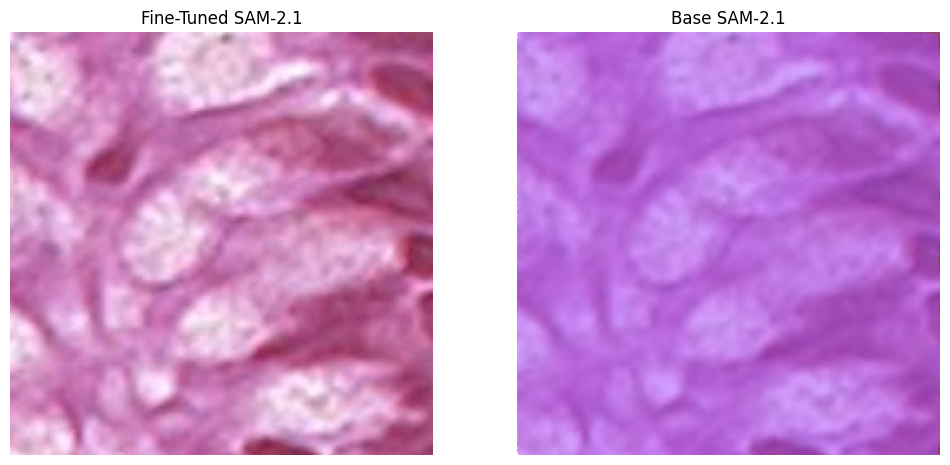

In [40]:
validation_set = os.listdir("/content/data/valid")

# choose random with .json extension
image = random.choice([img for img in validation_set if img.endswith(".jpg")])
image = os.path.join("/content/data/valid", image)
opened_image = np.array(Image.open(image).convert("RGB"))
result = mask_generator.generate(opened_image)

detections = sv.Detections.from_sam(sam_result=result)

mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)
annotated_image = opened_image.copy()
annotated_image = mask_annotator.annotate(annotated_image, detections=detections)

base_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)

base_result = mask_generator_base.generate(opened_image)
base_detections = sv.Detections.from_sam(sam_result=base_result)
base_annotated_image = opened_image.copy()
base_annotated_image = base_annotator.annotate(base_annotated_image, detections=base_detections)

sv.plot_images_grid(images=[annotated_image, base_annotated_image], titles=["Fine-Tuned SAM-2.1", "Base SAM-2.1"], grid_size=(1, 2))

Poor results as compared to UNet

In [27]:
!ls sam2/configs/sam2.1

sam2.1_hiera_b+.yaml  sam2.1_hiera_s.yaml
sam2.1_hiera_l.yaml   sam2.1_hiera_t.yaml


In [28]:
import shutil

# Define source and destination paths
files_to_move = {
    "/content/sam2/sam2_logs/configs/train.yaml/checkpoints/checkpoint.pt": "/kaggle/working/checkpoint.pt",
    "sam2/configs/sam2.1/sam2.1_hiera_b+.yaml": "/kaggle/working/sam2.1_hiera_b+.yaml",
    "/content/sam2/checkpoints/sam2.1_hiera_base_plus.pt": "/kaggle/working/sam2.1_hiera_base_plus.pt"
}

# Move files
for src, dst in files_to_move.items():
    shutil.copy(src, dst)
    print(f"Copied {src} to {dst}")

Copied /content/sam2/sam2_logs/configs/train.yaml/checkpoints/checkpoint.pt to /kaggle/working/checkpoint.pt
Copied sam2/configs/sam2.1/sam2.1_hiera_b+.yaml to /kaggle/working/sam2.1_hiera_b+.yaml
Copied /content/sam2/checkpoints/sam2.1_hiera_base_plus.pt to /kaggle/working/sam2.1_hiera_base_plus.pt


In [33]:
%cd ..
%cd ..

/


In [37]:
%cd kaggle/working

/kaggle/working
